# Combine All Datasets

> One dataset to rule them all, and in the darkness, bind them.

In [22]:
%load_ext autoreload
%autoreload 2

from helpers import plotLightCurveFromDF, saveLightCurveFromDF, sampleRandomKIC


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---

In [2]:
%%time
K2VARCAT = pd.read_pickle(r"../data/saved-dataframes/K2VARCAT-C-00.pkl")
KCC = pd.read_parquet(r"../data/saved-dataframes/KCC-stitched.parquet")
KEB = pd.read_pickle(r"../data/saved-dataframes/KEB.pkl")


CPU times: user 7.72 s, sys: 7.73 s, total: 15.5 s
Wall time: 11.6 s


---

## Format the K2 Variable Catalog

1. Change classes
2. Drop unnecessary columns
3. Save new parquet set

In [3]:
K2VARCAT.shape


(7748, 13)

In [4]:
K2VARCAT.index.name = "KIC"
K2VARCAT = K2VARCAT.drop(columns=["Campaign"])



In [5]:
print(K2VARCAT['Class'].value_counts())


Class
 Noise    4476
OTHPER    2548
 DSCUT     263
  GDOR     161
    EA     149
    EB     143
  RRab       8
Name: count, dtype: int64


<Axes: >

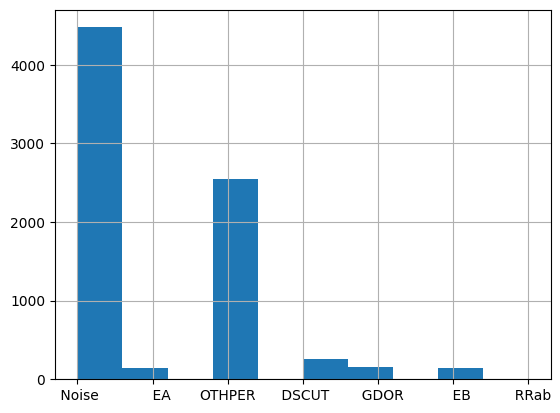

In [6]:
K2VARCAT['Class'].hist()


In [ ]:
K2VARCAT["Class_clean"] = K2VARCAT["Class"].astype(str).str.strip().str.upper()
K2VARCAT["Class_new"] = "Variable Star"

# Apply rules
K2VARCAT.loc[
    K2VARCAT["Class_clean"].isin(["EA", "EB"]),
    "Class_new"
] = "Eclipsing Binary Star"

K2VARCAT.loc[
    K2VARCAT["Class_clean"] == "NOISE",
    "Class_new"
] = "False Positive"

# Replace original column
K2VARCAT = K2VARCAT.drop(columns=["Class"]).rename(columns={"Class_new": "Class"})


In [8]:
K2VARCAT['Class'].value_counts()


Class
False Positive           4476
Variable Star            2980
Eclipsing Binary Star     292
Name: count, dtype: int64

<Axes: >

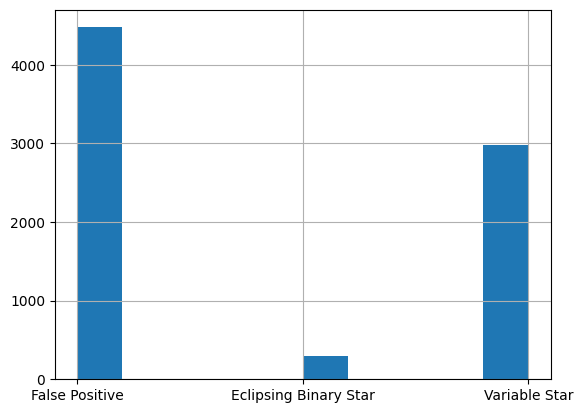

In [9]:
K2VARCAT['Class'].hist()


In [14]:
temp = (
    K2VARCAT
    .reset_index()
    [["KIC", "time", "flux", "Class"]]
)


In [15]:
K2VARCAT = temp.set_index("KIC")


In [17]:
K2VARCAT


,time,flux,Class
KIC,,,
202059070,"[1940.02801180377, 1940.0484434910104, 1940.06...","[1.0209611654281616, 0.999671220779419, 1.0258...",False Positive
202059073,"[1940.0078166502353, 1940.02824824032, 1940.04...","[0.9937425851821899, 0.99190354347229, 0.99378...",False Positive
202059074,"[1940.0078458546486, 1940.0487091504256, 1940....","[0.9949902296066284, 0.9948084354400635, 0.995...",False Positive
202059078,"[1940.0084669657808, 1940.0288985853185, 1940....","[0.9812511205673218, 0.9826586246490479, 0.979...",False Positive
202059080,"[1940.0084856754693, 1940.0289172976845, 1940....","[0.9239972829818726, 0.8829833269119263, 0.904...",False Positive
...,...,...,...
202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",Variable Star
202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",Variable Star
202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",False Positive


In [18]:
K2VARCAT.to_parquet("./local-assets/K2VARCAT_cleaned.parquet")


--- Plotting Light Curve for KIC 202091298 ---


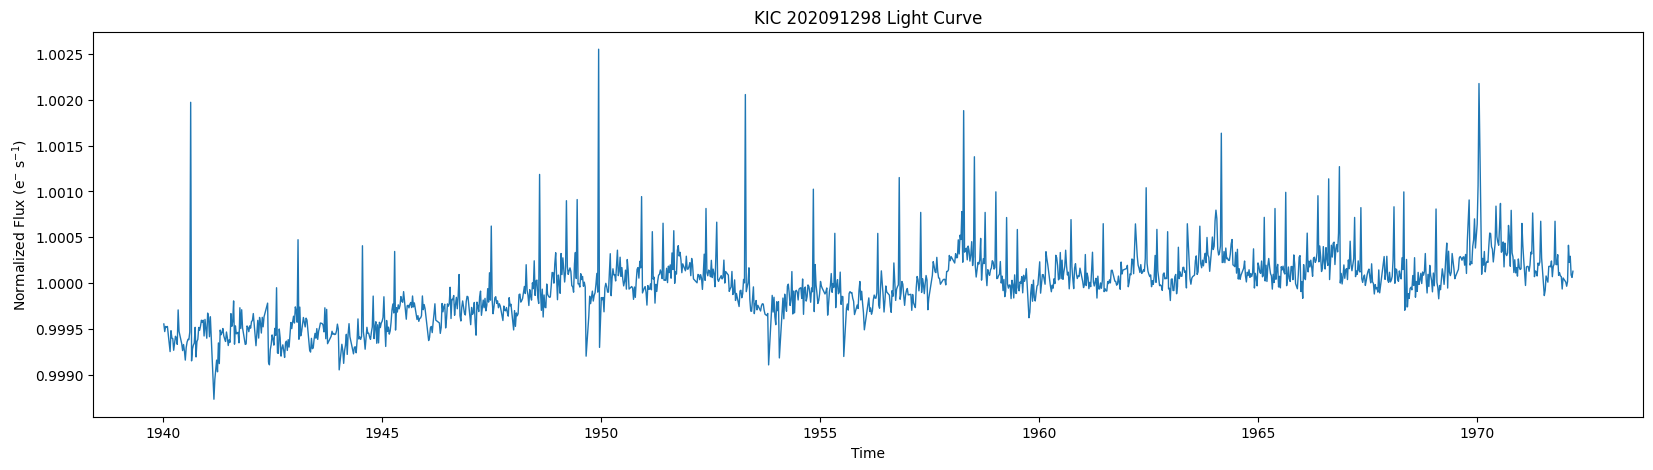

CPU times: user 62.1 ms, sys: 6.4 ms, total: 68.5 ms
Wall time: 80.1 ms


In [26]:
%%time
kic = sampleRandomKIC(K2VARCAT)
print(f"--- Plotting Light Curve for KIC {kic} ---")

plotLightCurveFromDF(K2VARCAT, kic)


---